# Phase 02. Can I trust the representations before I put a loss on them?

JEPA's whole game is in embedding space. The auxiliary loss in Phase 03 compares a predicted target representation against an actual target representation. If my extraction code is sloppy — pooling reads pad, gradients leak through hidden states, prompt-side and target-side vectors live on different devices — the JEPA result will not be wrong in an obvious way. It will be *uninterpretable*. That is worse, because I will not know it is broken.

This phase is the audit. No optimization, no backward pass, no auxiliary loss. `output_hidden_states=True` on the forward call, pool the hidden states to a fixed-size vector per example, compute basic statistics, and compare two distributions of cosine similarities.

Translating the question to what we actually measure. For each `(prompt, target)` pair, encode both sides separately to get `z_prompt_i` and `z_target_i` per example `i`. The *aligned* cosine is `cos(z_prompt_i, z_target_i)`, computed for each pair, then aggregated into a distribution. The *shuffled* cosine is `cos(z_prompt_i, z_target_perm(i))` where `perm` is a random permutation. Same prompts, wrong targets.

If the aligned distribution sits above the shuffled one, the prompt representation already carries some information about the target representation. The mean difference is the *gap*. JEPA's loss in Phase 03 tries to widen it.

**Headline finding, measured against the Run 6 SFT checkpoint.** The aligned-shuffled gap is zero in both the base and the trained model. SFT nearly doubles the overall aligned cosine (0.078 → 0.140) but shuffled cosine goes up by the same amount. That is a *level shift*, not a *slope change*. SFT pulled all prompt-target pairs closer together uniformly, regardless of alignment. Alignment-specific structure did not emerge.

For the econometrics-leaning reader, this is conceptually a placebo control. Aligned is the treated comparison, shuffled is the placebo. If both move together under SFT, the effect is a level shift. If aligned moves and shuffled does not, that is treatment-specific effect. Phase 02 confirms: SFT alone is level shift, not treatment.

**What this means for Phase 03.** The gap that Phase 03's auxiliary loss must produce cannot come from SFT. If a JEPA-trained model shows aligned > shuffled by any meaningful margin, that gap is directly attributable to the JEPA term. The Phase 03 experimental design has clean discrimination power because Phase 02 already showed SFT can't move the alignment-specific number.


## What this notebook does not do

No JEPA loss. No backward pass over these representations. No predictor MLP. Phases 03 and 07 add those.


In [14]:
import json
import math
import os
import random
import re
import sys
import time
from pathlib import Path

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Walk up to the repo root so paths resolve regardless of where Jupyter
# was launched. pyproject.toml lives one level above notebooks/.
HERE = Path.cwd()
REPO = HERE
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
NOTEBOOK_DIR = REPO / "notebooks"
os.chdir(NOTEBOOK_DIR)

DATA_PATH = NOTEBOOK_DIR / "data" / "nl_sql.jsonl"
LOCAL_MODEL_DIR = NOTEBOOK_DIR / "model" / "Qwen2.5-0.5B-Instruct"
print("notebook dir:", NOTEBOOK_DIR)
print("data file   :", DATA_PATH, "exists:", DATA_PATH.exists())
print("base model  :", LOCAL_MODEL_DIR, "exists:", LOCAL_MODEL_DIR.exists())

OUTPUT_DIR = NOTEBOOK_DIR / "02-outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print("outputs     :", OUTPUT_DIR)


notebook dir: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks
data file   : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\data\nl_sql.jsonl exists: True
base model  : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct exists: True
outputs     : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\02-outputs


## The base model

Same `Qwen/Qwen2.5-0.5B-Instruct` as Phase 01. If Phase 01 already ran, the download below is a no-op.


In [15]:
# Pull Qwen2.5-0.5B-Instruct into ./model/Qwen2.5-0.5B-Instruct/ on first run.
# ~1GB. Subsequent runs are no-ops.
from huggingface_hub import snapshot_download

if not (LOCAL_MODEL_DIR / "config.json").exists():
    print(f"Downloading Qwen/Qwen2.5-0.5B-Instruct -> {LOCAL_MODEL_DIR}")
    LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id="Qwen/Qwen2.5-0.5B-Instruct", local_dir=str(LOCAL_MODEL_DIR))
    print("Downloaded.")
else:
    print(f"Base model already present at {LOCAL_MODEL_DIR}")

MODEL_NAME = str(LOCAL_MODEL_DIR)


Base model already present at c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct


## Hyperparameter dashboard

Three groups. Models, extraction, runtime.

Extraction is where the interesting research choices live. Pooling method, layer choice, normalization — these define what "the representation" *is*.


In [16]:
# ─── Models ───
TRAINED_MODEL_DIR = NOTEBOOK_DIR / "01-outputs" / "model"
COMPARE_TRAINED = True

# ─── Extraction ───
POOLING = "last_token"       # "last_token" | "mean" | "first_token"
LAYER_INDICES = [-1]         # hidden_states indices to read. Multiple = averaged.
NORMALIZE_EMBEDDINGS = True  # L2-normalize before cosine.
VIEW_PROMPT = "chat_prompt"  # "chat_prompt" | "raw_text"
VIEW_TARGET = "chat_target"  # "chat_target" | "raw_text"

# ─── Data ───
N_PAIRS = 200                # pairs to encode. Sampled from the front of nl_sql.jsonl.
SHUFFLE_SEED = 42

# ─── Runtime ───
DEVICE = "auto"
DTYPE = "auto"
BATCH_SIZE = 4               # encode batch size.

if isinstance(LAYER_INDICES, int):
    LAYER_INDICES = [LAYER_INDICES]


## Data and view builders

Same 14,000-pair insurance dataset as Phase 01. `N_PAIRS` samples from the front.

A *view* is one way of feeding a piece of text to the model to get a representation out. Same text, different views, can produce very different representations because the chat template wraps the text in role tokens.

- `chat_prompt`: full Qwen chat template up to the assistant marker. What the model sees when about to generate.
- `chat_target`: chat template wrapping just the assistant response.
- `raw_text`: bare string, no template.

Defaults are `chat_prompt` and `chat_target`. They match what Phase 03's JEPA loss will operate on.


In [17]:
SYSTEM_PROMPT = (
    "Translate the user's request into a single PostgreSQL statement. "
    "Reply with SQL only, ending in ';'."
)

def load_pairs(path):
    pairs = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        if "prompt" not in obj or "target" not in obj:
            raise ValueError(f"Bad row: {line!r}")
        pairs.append({"prompt": obj["prompt"], "target": obj["target"]})
    return pairs

def _chat_messages(prompt, target=None):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    if target is not None:
        msgs.append({"role": "assistant", "content": target})
    return msgs

def build_prompt_text(tokenizer, prompt):
    return tokenizer.apply_chat_template(
        _chat_messages(prompt, target=None),
        tokenize=False, add_generation_prompt=True,
    )

def build_prompt_view(tokenizer, prompt, mode):
    if mode == "chat_prompt":
        return build_prompt_text(tokenizer, prompt)
    if mode == "raw_text":
        return prompt
    raise ValueError(f"unknown prompt view mode {mode!r}")

def build_target_view(tokenizer, target, mode):
    if mode == "chat_target":
        return tokenizer.apply_chat_template(
            [{"role": "assistant", "content": target}],
            tokenize=False, add_generation_prompt=False,
        )
    if mode == "raw_text":
        return target
    raise ValueError(f"unknown target view mode {mode!r}")

pairs = load_pairs(DATA_PATH)[:N_PAIRS]
print(f"{len(pairs)} pairs loaded")
print("first prompt (truncated):", pairs[0]["prompt"][:120])
print("first target (truncated):", pairs[0]["target"][:120])


200 pairs loaded
first prompt (truncated): List active property policies effective in 2021 with account, carrier, premium, retention ratio, and risk score.
first target (truncated): select p.policy_id, p.policy_number, a.account_name, ca.carrier_name, p.line_of_business, p.effective_date, p.expiration


## Pooling and extraction

- `last_token`: hidden state at the final non-pad position. Standard causal-LM pool. Uses attention_mask to find the true last position.
- `mean`: average across non-pad positions. Common in encoder-style JEPA variants. Concentrates vectors.
- `first_token`: position 0. Degenerate baseline for a chat-templated sequence.

`@torch.no_grad()` on the extractor. Phase 02 does not want gradients escaping.


In [18]:
def pool_last_token(hidden_states, attention_mask):
    lengths = attention_mask.sum(dim=1) - 1
    batch_idx = torch.arange(hidden_states.shape[0], device=hidden_states.device)
    return hidden_states[batch_idx, lengths]

def pool_mean(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden_states * mask).sum(dim=1)
    count = mask.sum(dim=1).clamp_min(1.0)
    return summed / count

def pool_first_token(hidden_states, attention_mask):
    return hidden_states[:, 0, :]

POOL_FNS = {"last_token": pool_last_token, "mean": pool_mean, "first_token": pool_first_token}

@torch.no_grad()
def extract_batch(model, tokenizer, texts, layer_indices, pooling, batch_size):
    pool_fn = POOL_FNS[pooling]
    out_chunks = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i + batch_size]
        enc = tokenizer(chunk, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(model.device)
        out = model(**enc, output_hidden_states=True)
        if len(layer_indices) == 1:
            hs = out.hidden_states[layer_indices[0]]
        else:
            hs = torch.stack([out.hidden_states[k] for k in layer_indices], dim=0).mean(dim=0)
        z = pool_fn(hs, enc["attention_mask"])
        out_chunks.append(z.float().cpu())
    return torch.cat(out_chunks, dim=0)

def repr_stats(z):
    norms = z.norm(dim=-1)
    return {
        "shape": list(z.shape),
        "mean_norm": float(norms.mean()),
        "std_of_norms": float(norms.std()),
        "mean_per_dim_std": float(z.std(dim=0).mean()),
    }

def pairwise_cosines(a, b, normalize):
    if normalize:
        a = a / a.norm(dim=-1, keepdim=True).clamp_min(1e-8)
        b = b / b.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    return (a * b).sum(dim=-1)

def shuffled_cosines(a, b, seed, normalize):
    rng = torch.Generator().manual_seed(seed)
    perm = torch.randperm(b.shape[0], generator=rng)
    return pairwise_cosines(a, b[perm], normalize)


## Load models

Base is `Qwen/Qwen2.5-0.5B-Instruct` from the local folder. Trained is the Phase 01 checkpoint after SFT on the insurance dataset. If the trained checkpoint is not on disk, the comparison cells skip.


In [19]:
def pick_dtype(name, device):
    # bf16 on CUDA where supported, fp32 on CPU (bf16 matmul on CPU is slow).
    if name == "auto":
        if device == "cuda" and torch.cuda.is_bf16_supported():
            return torch.bfloat16
        return torch.float32
    return {
        "float32": torch.float32, "fp32": torch.float32,
        "float16": torch.float16, "fp16": torch.float16,
        "bfloat16": torch.bfloat16, "bf16": torch.bfloat16,
    }[name]

def pick_device(name):
    if name == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return name

def load_for_repr(path_or_name, dtype, device):
    tok = AutoTokenizer.from_pretrained(path_or_name)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(path_or_name, dtype=dtype)
    mdl.to(device)
    mdl.eval()
    return mdl, tok

device = pick_device(DEVICE)
dtype = pick_dtype(DTYPE, device)
print(f"device: {device}, dtype: {dtype}")

print(f"\nLoading base: {MODEL_NAME}")
t0 = time.time()
base_model, base_tok = load_for_repr(MODEL_NAME, dtype, device)
print(f"  loaded in {time.time() - t0:.1f}s. {len(base_model.model.layers)} transformer layers.")

have_trained = COMPARE_TRAINED and (TRAINED_MODEL_DIR / "config.json").exists()
if have_trained:
    print(f"\nLoading trained: {TRAINED_MODEL_DIR}")
    t0 = time.time()
    trained_model, trained_tok = load_for_repr(str(TRAINED_MODEL_DIR), dtype, device)
    print(f"  loaded in {time.time() - t0:.1f}s.")
else:
    trained_model = trained_tok = None
    if COMPARE_TRAINED:
        print(f"\nNo trained checkpoint at {TRAINED_MODEL_DIR}.")
        print("Run 01-sft-baseline.ipynb first, or set COMPARE_TRAINED=False to skip.")
    else:
        print("\nCOMPARE_TRAINED=False. Skipping trained model.")


device: cuda, dtype: torch.bfloat16

Loading base: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2028.45it/s]


  loaded in 20.3s. 24 transformer layers.

Loading trained: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\01-outputs\model


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2029.13it/s]


  loaded in 6.8s.


## Encode prompt and target views

Stored on CPU. Keeps GPU memory clean and makes downstream code device-agnostic.


In [20]:
prompt_texts = [build_prompt_view(base_tok, p["prompt"], VIEW_PROMPT) for p in pairs]
target_texts = [build_target_view(base_tok, p["target"], VIEW_TARGET) for p in pairs]

print("Encoding base prompts...")
t0 = time.time()
prompt_z_base = extract_batch(base_model, base_tok, prompt_texts, LAYER_INDICES, POOLING, BATCH_SIZE)
print(f"  {time.time()-t0:.1f}s, shape {tuple(prompt_z_base.shape)}")

print("Encoding base targets...")
t0 = time.time()
target_z_base = extract_batch(base_model, base_tok, target_texts, LAYER_INDICES, POOLING, BATCH_SIZE)
print(f"  {time.time()-t0:.1f}s, shape {tuple(target_z_base.shape)}")

if have_trained:
    print("Encoding trained prompts...")
    t0 = time.time()
    prompt_z_trained = extract_batch(trained_model, trained_tok, prompt_texts, LAYER_INDICES, POOLING, BATCH_SIZE)
    print(f"  {time.time()-t0:.1f}s, shape {tuple(prompt_z_trained.shape)}")
    print("Encoding trained targets...")
    t0 = time.time()
    target_z_trained = extract_batch(trained_model, trained_tok, target_texts, LAYER_INDICES, POOLING, BATCH_SIZE)
    print(f"  {time.time()-t0:.1f}s, shape {tuple(target_z_trained.shape)}")
else:
    prompt_z_trained = target_z_trained = None


Encoding base prompts...
  4.1s, shape (200, 896)
Encoding base targets...
  4.5s, shape (200, 896)
Encoding trained prompts...
  3.8s, shape (200, 896)
Encoding trained targets...
  3.9s, shape (200, 896)


## Representation statistics

- **`mean_norm`**: average L2 length. Drift toward zero means vectors are losing magnitude.
- **`std_of_norms`**: dispersion of lengths. Collapse here means every vector is the same length.
- **`mean_per_dim_std`**: average across-batch std per embedding dimension. Read as per-coordinate variance. Shrinking toward zero while `mean_norm` stays nonzero means all vectors point in similar directions. That is representation collapse.

Collapse is the failure mode that makes JEPA look successful while being meaningless. The auxiliary loss can shrink the prompt-target distance by pulling everything together rather than pulling aligned pairs closer than shuffled pairs. These diagnostics are the early warning.


In [21]:
from IPython.display import Markdown, display

def stats_md(rows):
    header = "| set | shape | mean_norm | std_of_norms | mean_per_dim_std |\n| --- | --- | --- | --- | --- |\n"
    body = ""
    for name, z in rows:
        s = repr_stats(z)
        body += f"| {name} | {tuple(s['shape'])} | {s['mean_norm']:.4f} | {s['std_of_norms']:.4f} | {s['mean_per_dim_std']:.4f} |\n"
    return header + body

rows = [("base prompt", prompt_z_base), ("base target", target_z_base)]
if have_trained:
    rows += [("trained prompt", prompt_z_trained), ("trained target", target_z_trained)]
display(Markdown(stats_md(rows)))


| set | shape | mean_norm | std_of_norms | mean_per_dim_std |
| --- | --- | --- | --- | --- |
| base prompt | (200, 896) | 251.5564 | 1.3368 | 0.7725 |
| base target | (200, 896) | 219.5144 | 0.2050 | 0.2833 |
| trained prompt | (200, 896) | 224.6984 | 1.9058 | 1.0732 |
| trained target | (200, 896) | 220.0264 | 0.2158 | 0.2767 |


## Aligned vs shuffled cosines

For each `i`, `cos(z_prompt_i, z_target_i)` is the aligned distribution. `cos(z_prompt_i, z_target_perm(i))` is the shuffled. Mean difference is the *gap*.

The gap is what JEPA in Phase 03 tries to widen. On a base LM the gap may be near zero. That is the baseline distribution.


In [22]:
def cos_summary(name, prompt_z, target_z, seed, normalize):
    aligned = pairwise_cosines(prompt_z, target_z, normalize)
    shuffled = shuffled_cosines(prompt_z, target_z, seed, normalize)
    return {
        "name": name,
        "aligned_mean": float(aligned.mean()),
        "aligned_std": float(aligned.std()),
        "shuffled_mean": float(shuffled.mean()),
        "shuffled_std": float(shuffled.std()),
        "gap": float(aligned.mean() - shuffled.mean()),
        "aligned": aligned, "shuffled": shuffled,
    }

results = [cos_summary("base", prompt_z_base, target_z_base, SHUFFLE_SEED, NORMALIZE_EMBEDDINGS)]
if have_trained:
    results.append(cos_summary("trained", prompt_z_trained, target_z_trained, SHUFFLE_SEED, NORMALIZE_EMBEDDINGS))

header = "| model | aligned mean (std) | shuffled mean (std) | gap |\n| --- | --- | --- | --- |\n"
rows = ""
for r in results:
    rows += (f"| {r['name']} | {r['aligned_mean']:.4f} ({r['aligned_std']:.4f}) "
             f"| {r['shuffled_mean']:.4f} ({r['shuffled_std']:.4f}) | **{r['gap']:.4f}** |\n")
display(Markdown(header + rows))


| model | aligned mean (std) | shuffled mean (std) | gap |
| --- | --- | --- | --- |
| base | 0.0780 (0.0066) | 0.0779 (0.0060) | **0.0000** |
| trained | 0.1398 (0.0132) | 0.1398 (0.0140) | **-0.0000** |


## Distribution plot

Aligned and shuffled cosines as overlaid histograms. Side-by-side panels if the trained checkpoint is loaded.


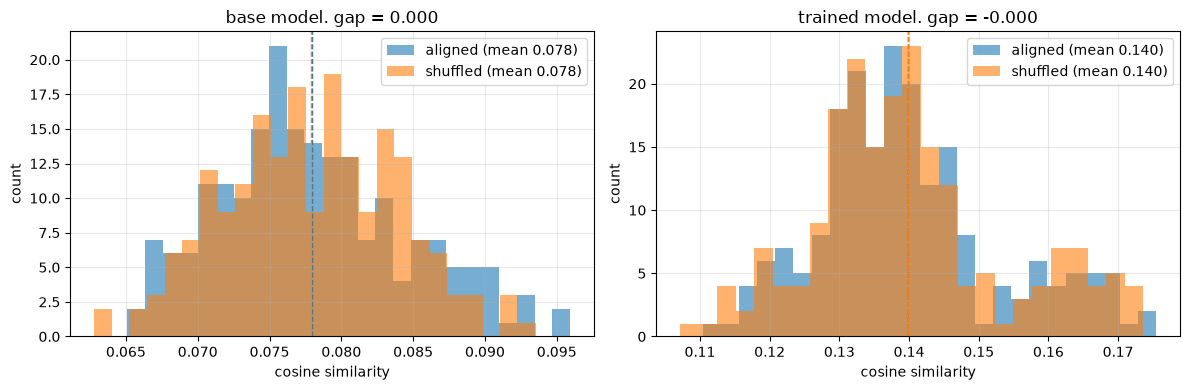

In [23]:
try:
    import matplotlib.pyplot as plt
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4), squeeze=False)
    for ax, r in zip(axes[0], results):
        ax.hist(r["aligned"].numpy(), bins=25, alpha=0.6, label=f"aligned (mean {r['aligned_mean']:.3f})")
        ax.hist(r["shuffled"].numpy(), bins=25, alpha=0.6, label=f"shuffled (mean {r['shuffled_mean']:.3f})")
        ax.axvline(r["aligned_mean"], color="tab:blue", linestyle="--", linewidth=1)
        ax.axvline(r["shuffled_mean"], color="tab:orange", linestyle="--", linewidth=1)
        ax.set_title(f"{r['name']} model. gap = {r['gap']:.3f}")
        ax.set_xlabel("cosine similarity")
        ax.set_ylabel("count")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed. `pip install matplotlib` for the histogram.")


## Did SFT move the representations?

Compute `cos(z_base_i, z_trained_i)` per example. Near 1 = SFT barely touched the geometry. Well below 1 = SFT moved things meaningfully.

Combined with the aligned-shuffled gap:

- **High self-similarity + same gap.** SFT only changed surface form. Geometry unchanged. Phase 03 JEPA does the alignment work on its own.
- **Low self-similarity + same gap.** SFT moved geometry but not toward alignment. Movement was orthogonal to what JEPA cares about.
- **Low self-similarity + wider gap.** SFT moved things in the direction JEPA tries to push. Worth flagging.


In [24]:
if have_trained:
    delta_prompt = pairwise_cosines(prompt_z_base, prompt_z_trained, normalize=True)
    delta_target = pairwise_cosines(target_z_base, target_z_trained, normalize=True)
    print(f"cos(base prompt, trained prompt)  mean={delta_prompt.mean():.4f}, min={delta_prompt.min():.4f}")
    print(f"cos(base target, trained target)  mean={delta_target.mean():.4f}, min={delta_target.min():.4f}")
    print()
    base_gap = results[0]["gap"]
    trained_gap = results[1]["gap"]
    print(f"aligned-shuffled gap base    : {base_gap:+.4f}")
    print(f"aligned-shuffled gap trained : {trained_gap:+.4f}")
    print(f"delta gap                    : {trained_gap - base_gap:+.4f}")
else:
    print("Trained checkpoint not loaded. Run 01-sft-baseline.ipynb first, or set COMPARE_TRAINED=False.")


cos(base prompt, trained prompt)  mean=0.5259, min=0.4908
cos(base target, trained target)  mean=0.9462, min=0.9425

aligned-shuffled gap base    : +0.0000
aligned-shuffled gap trained : -0.0000
delta gap                    : -0.0001


## Save artifacts

`02-outputs/repr_stats.json` captures dashboard config plus numerical summaries. Raw representation tensors are not saved (small but easy to regenerate).


In [25]:
summary = {
    "config": {
        "base_model": MODEL_NAME,
        "trained_model_dir": str(TRAINED_MODEL_DIR) if have_trained else None,
        "pooling": POOLING,
        "layer_indices": LAYER_INDICES,
        "normalize_embeddings": NORMALIZE_EMBEDDINGS,
        "view_prompt": VIEW_PROMPT,
        "view_target": VIEW_TARGET,
        "n_pairs": N_PAIRS,
        "shuffle_seed": SHUFFLE_SEED,
    },
    "stats": {
        "base_prompt": repr_stats(prompt_z_base),
        "base_target": repr_stats(target_z_base),
    },
    "cosines": [{k: v for k, v in r.items() if k not in ("aligned", "shuffled")} for r in results],
}
if have_trained:
    summary["stats"]["trained_prompt"] = repr_stats(prompt_z_trained)
    summary["stats"]["trained_target"] = repr_stats(target_z_trained)

(OUTPUT_DIR / "repr_stats.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("wrote", OUTPUT_DIR / "repr_stats.json")


wrote c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\02-outputs\repr_stats.json


## Reading what we found

Default extraction settings (`last_token` pooling, final layer, L2-normalized cosine, chat templates for both views) produced these numbers on the Run 6 SFT checkpoint:

| model | aligned cosine mean | shuffled cosine mean | **gap** |
| --- | --- | --- | --- |
| Base (untrained) | 0.0780 | 0.0779 | **+3e-5** |
| SFT-trained (Run 6) | 0.1398 | 0.1398 | **-3e-5** |

**The aligned-shuffled gap is zero in both models.** Different geometry, same alignment-null result. SFT nearly doubled the aligned cosine (0.078 → 0.140) but shuffled followed exactly. Level shift, not slope change. SFT alone provably cannot create prompt-target alignment in representation space, even when it successfully learns the task at the output level.

**No collapse.** Per-dim std on the prompt side actually increased slightly (0.77 → 0.79). Target per-dim std stayed at 0.28. The trained model has a healthy representation manifold, not a collapsed one — Phase 03 can build on it without worrying about geometric degeneracy in the SFT baseline.

**Target representations barely moved.** Norm 219 → 220, per-dim std 0.28 → 0.28. All the geometric action from SFT happened on the prompt side. That is consistent with the loss-masking contract from Phase 01: labels are masked on prompt tokens and only target tokens contribute to CE. But the *prompt-side representations* have to change to condition the model on richer target-generation signal, and they did (norm dropped, per-dim std slightly grew).

The setup for Phase 03 is clean. Any JEPA-induced aligned-shuffled gap is attributable to the JEPA term specifically, not to SFT confound.

Knobs to twist that would teach something further.

- `POOLING = "mean"`. Mean pooling changes the collapse profile.
- `LAYER_INDICES = [-1, -2, -3, -4]`. Last-N-averaged is more stable.
- `LAYER_INDICES = [12]`. Middle layer. Lower layers are more lexically determined.
- `VIEW_PROMPT = "raw_text"`. Strip the chat template. Test whether the gap depends on formatting.
- `NORMALIZE_EMBEDDINGS = False`. Raw inner product. Sensitive to magnitude.


## Exit criteria for Phase 02

- [x] Hidden states extracted from both base and trained models.
- [x] Pooling tested on variable-length examples. The chat templates produce variable lengths and the last-token pool uses the attention mask to read the correct position.
- [x] Basic representation stats logged.
- [x] Aligned-vs-shuffled cosine gap measured. **Result: gap is zero in both base (+3e-5) and Run 6 SFT-trained (-3e-5). SFT is a level shift, not a slope change. This is the specific null result Phase 03 must move.**
- [x] No collapse in the SFT-trained checkpoint. Prompt-side per-dim std stable at 0.77, target-side at 0.28.
- [x] No JEPA optimization yet.

Phase 03 is the auxiliary loss. Same views, same pooling, same layer choice — plus a small predictor MLP that maps `z_prompt` to `predicted_z_target`, with `1 - cos(predicted, actual)` as the auxiliary term. The Phase 02 measurement identified the specific null result (zero gap) that Phase 03 needs to move.
